# Political Feature Vectors - Israel Cantons Project

This notebook creates political feature vectors for clustering using **pluggable representations** from `src/data/representations.py`:

1. **BlocShares** — Manual 5-bloc grouping (right, haredi, center, left, arab)
2. **RawPartyShares** — Average raw party vote percentages (~100+ features)
3. **PCARepresentation** — PCA on raw party shares (latent dimensions)
4. **NMFRepresentation** — NMF on raw party shares (non-negative latent blocs)

All representations implement the same `Representation` protocol for pluggability.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.config import DATA_PROCESSED, BLOC_COLS
from src.data.processing import process_all_elections
from src.data.representations import BlocShares, RawPartyShares, PCARepresentation, NMFRepresentation

DATA_PROCESSED.mkdir(exist_ok=True)
print("Setup complete")

Setup complete


## 1. Load Processed Elections

In [2]:
elections = process_all_elections()
print(f"Loaded {len(elections)} elections:")
for k, df in elections.items():
    print(f"  Knesset {k}: {len(df)} municipalities")

Loaded 5 elections:
  Knesset 21: 229 municipalities
  Knesset 22: 229 municipalities
  Knesset 23: 229 municipalities
  Knesset 24: 229 municipalities
  Knesset 25: 229 municipalities


## 2. Representation 1: Bloc Shares (Manual 5-Bloc Grouping)

In [3]:
bloc_repr = BlocShares(include_std=True)
bloc_features = bloc_repr.fit_transform(elections)

print(f"BlocShares: {bloc_features.shape[0]} municipalities, {len(bloc_repr.feature_names)} features")
print(f"Features: {bloc_repr.feature_names}")
print(f"\nDescriptive statistics:")
print(bloc_features.describe().round(1))

BlocShares: 229 municipalities, 11 features
Features: ['right_avg', 'right_std', 'haredi_avg', 'haredi_std', 'center_avg', 'center_std', 'left_avg', 'left_std', 'arab_avg', 'arab_std', 'avg_votes']

Descriptive statistics:
       right_avg  right_std  haredi_avg  haredi_std  center_avg  center_std  \
count      229.0      229.0       229.0       229.0       229.0       229.0   
mean        29.3        2.8         7.5         1.2        25.2         3.5   
std         22.1        2.7        13.7         1.2        19.4         3.1   
min          0.4        0.2         0.1         0.1         0.4         0.1   
25%          5.9        1.1         0.9         0.4         5.3         1.8   
50%         28.5        2.0         2.7         0.8        23.8         2.8   
75%         49.5        3.4         8.8         1.5        43.1         4.3   
max         73.2       14.8        89.2         9.2        66.0        19.8   

       left_avg  left_std  arab_avg  arab_std  avg_votes  
count 

In [4]:
# Sample bloc profiles for well-known municipalities
sample_cities = ['תל אביב -יפו', 'ירושלים', 'חיפה', 'באר שבע', 'בני ברק', 'אום אל-פחם']
blocs = BLOC_COLS

print("Sample bloc profiles:")
print("=" * 80)
for city in sample_cities:
    row = bloc_features[bloc_features['municipality'] == city]
    if len(row) > 0:
        row = row.iloc[0]
        print(f"\n{city}:")
        for bloc in blocs:
            pct = row[f'{bloc}_avg']
            bar = '█' * int(pct / 2)
            print(f"  {bloc:8s}: {pct:5.1f}% {bar}")

Sample bloc profiles:

תל אביב -יפו:
  right   :  25.8% ████████████
  haredi  :   4.8% ██
  center  :  44.3% ██████████████████████
  left    :  20.5% ██████████
  arab    :   3.2% █

ירושלים:
  right   :  36.2% ██████████████████
  haredi  :  40.2% ████████████████████
  center  :  12.9% ██████
  left    :   6.2% ███
  arab    :   1.5% 

חיפה:
  right   :  37.8% ██████████████████
  haredi  :   6.5% ███
  center  :  35.3% █████████████████
  left    :  10.2% █████
  arab    :   8.4% ████

באר שבע:
  right   :  63.6% ███████████████████████████████
  haredi  :   9.3% ████
  center  :  19.9% █████████
  left    :   4.1% ██
  arab    :   0.6% 

בני ברק:
  right   :   7.8% ███
  haredi  :  89.2% ████████████████████████████████████████████
  center  :   1.4% 
  left    :   0.4% 
  arab    :   0.0% 

אום אל-פחם:
  right   :   0.7% 
  haredi  :   0.2% 
  center  :   0.8% 
  left    :   2.3% █
  arab    :  95.4% ███████████████████████████████████████████████


## 3. Representation 2: Raw Party Shares

In [5]:
raw_repr = RawPartyShares()
raw_features = raw_repr.fit_transform(elections)

print(f"RawPartyShares: {raw_features.shape[0]} municipalities, {len(raw_repr.feature_names)} features")
print(f"Sample features: {raw_repr.feature_names[:10]} ...")
print(f"\nAll values non-negative: {(raw_features.drop(columns=['municipality']) >= 0).all().all()}")

RawPartyShares: 229 municipalities, 79 features
Sample features: ['Unnamed: 37', 'Unnamed: 46', 'אמת', 'אצ', 'ב', 'ג', 'ד', 'דעם', 'ודעם', 'ום'] ...

All values non-negative: True


## 4. Representation 3: PCA (Algorithmic Dimensionality Reduction)

In [6]:
pca_repr = PCARepresentation(n_components=5)
pca_features = pca_repr.fit_transform(elections)

print(f"PCA: {pca_features.shape[0]} municipalities, {len(pca_repr.feature_names)} components")
print(f"Features: {pca_repr.feature_names}")
print(f"\nExplained variance ratio: {pca_repr.explained_variance_ratio_}")
print(f"Total explained: {pca_repr.explained_variance_ratio_.sum():.1%}")

PCA: 229 municipalities, 5 components
Features: ['pc1', 'pc2', 'pc3', 'pc4', 'pc5']

Explained variance ratio: [0.63594844 0.19374286 0.07523721 0.02950638 0.01913503]
Total explained: 95.4%


## 5. Representation 4: NMF (Non-negative Latent Blocs)

In [7]:
nmf_repr = NMFRepresentation(n_components=5)
nmf_features = nmf_repr.fit_transform(elections)

print(f"NMF: {nmf_features.shape[0]} municipalities, {len(nmf_repr.feature_names)} components")
print(f"Features: {nmf_repr.feature_names}")
print(f"\nAll values non-negative: {(nmf_features.drop(columns=['municipality']) >= 0).all().all()}")
print(f"Components shape: {nmf_repr.components_.shape}")

NMF: 229 municipalities, 5 components
Features: ['nmf1', 'nmf2', 'nmf3', 'nmf4', 'nmf5']

All values non-negative: True
Components shape: (5, 79)


## 6. Compare Representations

In [8]:
print("Representation Summary:")
print("=" * 60)
reprs = [
    ("BlocShares", bloc_repr, bloc_features),
    ("RawPartyShares", raw_repr, raw_features),
    ("PCA(5)", pca_repr, pca_features),
    ("NMF(5)", nmf_repr, nmf_features),
]
for name, rep, df in reprs:
    n_feat = len(rep.feature_names)
    print(f"  {name:20s}: {n_feat:4d} features, {len(df)} municipalities")

Representation Summary:
  BlocShares          :   11 features, 229 municipalities
  RawPartyShares      :   79 features, 229 municipalities
  PCA(5)              :    5 features, 229 municipalities
  NMF(5)              :    5 features, 229 municipalities


## 7. Visualize Political Landscape

Municipalities by dominant bloc:
dominant_bloc
right     83
center    69
arab      68
haredi     8
left       1
Name: count, dtype: int64


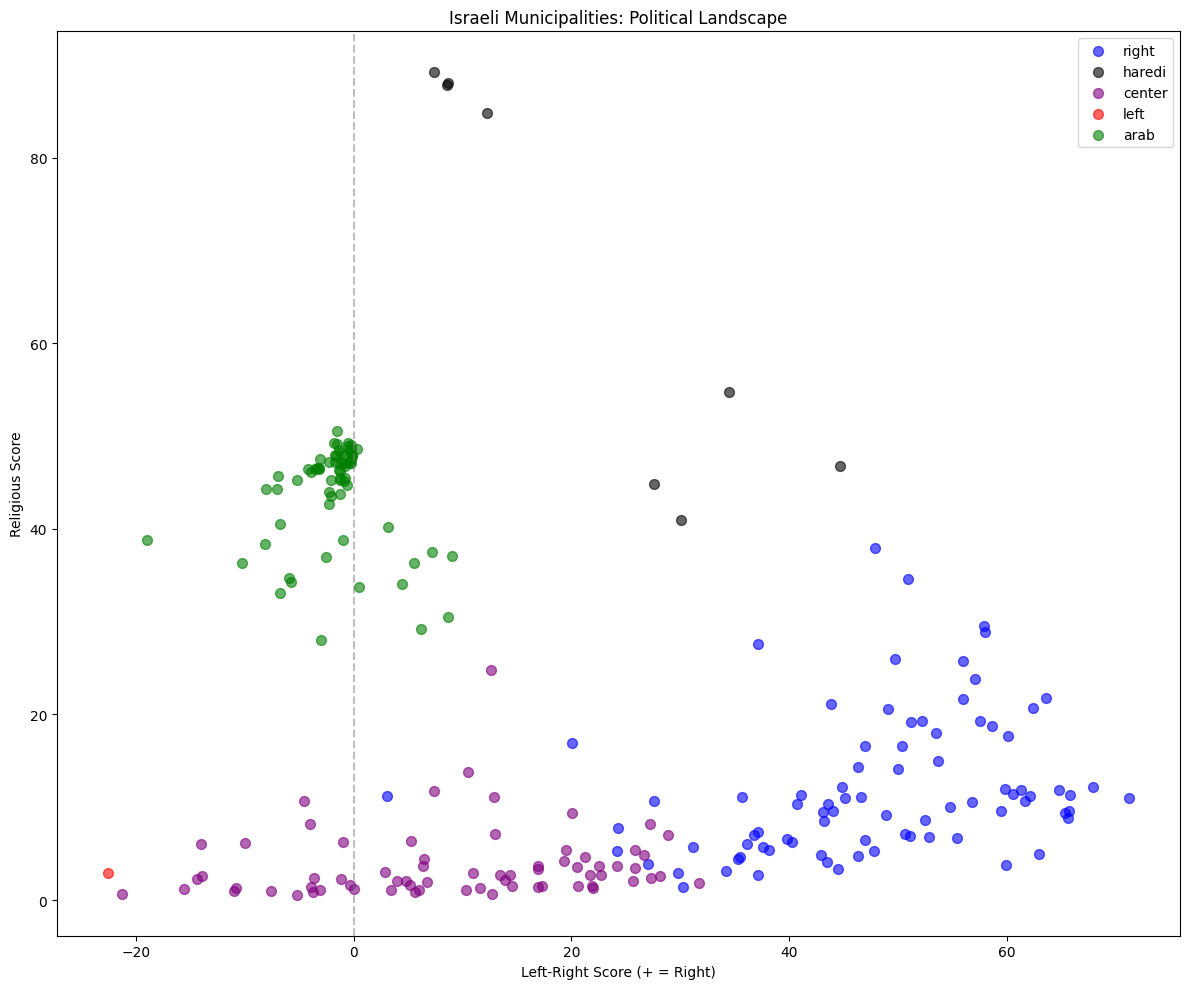

In [9]:
# Dominant bloc classification
def get_dominant_bloc(row):
    values = [row[f'{b}_avg'] for b in BLOC_COLS]
    return BLOC_COLS[np.argmax(values)]

bloc_features['dominant_bloc'] = bloc_features.apply(get_dominant_bloc, axis=1)
print("Municipalities by dominant bloc:")
print(bloc_features['dominant_bloc'].value_counts())

# 2D political landscape
bloc_features['left_right_score'] = bloc_features['right_avg'] - bloc_features['left_avg']
bloc_features['religious_score'] = bloc_features['haredi_avg'] + bloc_features['arab_avg'] * 0.5

colors = {'right': 'blue', 'haredi': 'black', 'center': 'purple', 'left': 'red', 'arab': 'green'}
fig, ax = plt.subplots(figsize=(12, 10))
for bloc in BLOC_COLS:
    subset = bloc_features[bloc_features['dominant_bloc'] == bloc]
    ax.scatter(subset['left_right_score'], subset['religious_score'],
               c=colors[bloc], label=bloc, alpha=0.6, s=50)
ax.set_xlabel('Left-Right Score (+ = Right)')
ax.set_ylabel('Religious Score')
ax.set_title('Israeli Municipalities: Political Landscape')
ax.legend()
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

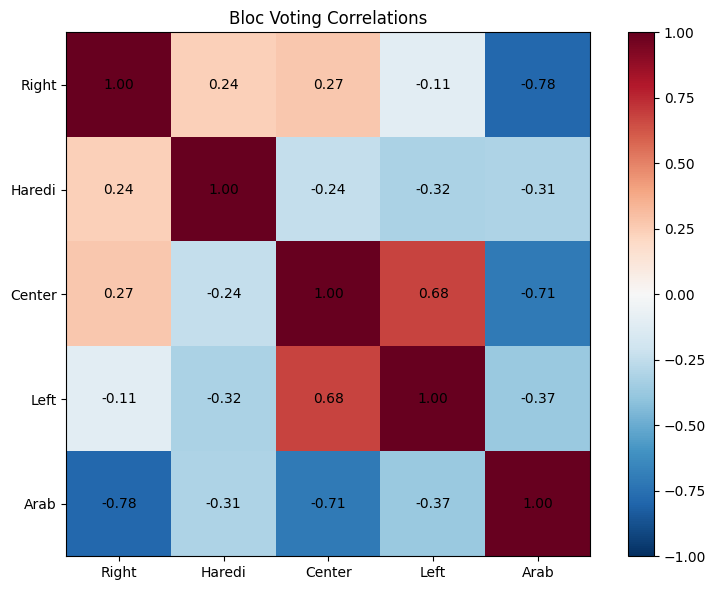

In [10]:
# Bloc correlation heatmap
bloc_avg_cols = [f'{b}_avg' for b in BLOC_COLS]
corr = bloc_features[bloc_avg_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(bloc_avg_cols)))
ax.set_yticks(range(len(bloc_avg_cols)))
ax.set_xticklabels([b.replace('_avg', '').title() for b in bloc_avg_cols])
ax.set_yticklabels([b.replace('_avg', '').title() for b in bloc_avg_cols])
plt.colorbar(im)
for i in range(len(bloc_avg_cols)):
    for j in range(len(bloc_avg_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
ax.set_title('Bloc Voting Correlations')
plt.tight_layout()
plt.show()

## 8. Save Feature Vectors

In [11]:
# Save bloc features (primary feature file)
bloc_features.to_csv(DATA_PROCESSED / 'political_features.csv', index=False, encoding='utf-8')
print(f"Saved political_features.csv ({len(bloc_features)} municipalities)")

print("\nDone — all 4 representations available via src.data.representations")

Saved political_features.csv (229 municipalities)

Done — all 4 representations available via src.data.representations
